# LLMs




```
# This is formatted as code
```

## Word Embedding Model

Building and training a small transformer embedding model on example text data. It should encode words into an embedding space where similar words are close to each other.

* Set up a small Transformer model, i.e., using `PyTorch`.
* Train the model on a small text corpus, e.g., generated yourself or from the web.
* Visualize the learned word embeddings using `t-SNE` or `PCA` in a 2D plot.

Make sure to use positional encodings in your transformer model to capture word order information.

epoch  40 | loss 2.7343
epoch  80 | loss 2.2303
epoch 120 | loss 1.4548
epoch 160 | loss 0.9125
epoch 200 | loss 1.4256
epoch 240 | loss 0.8484
epoch 280 | loss 0.6686
epoch 320 | loss 0.5070
epoch 360 | loss 0.6996
epoch 400 | loss 0.2264
Training done.


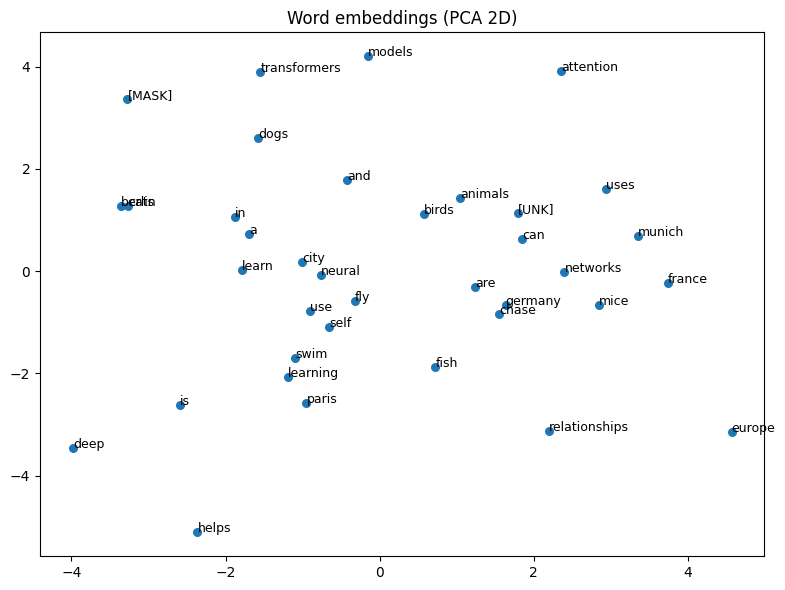

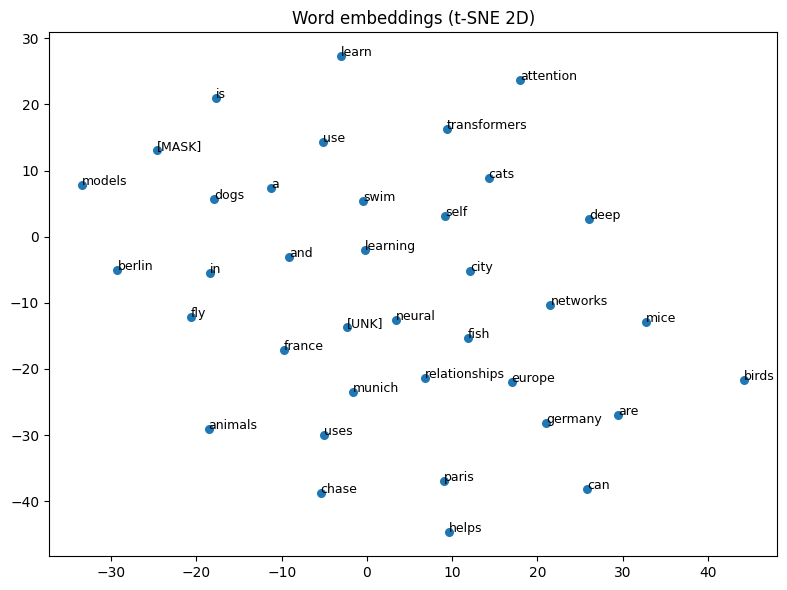

In [ ]:
#  Word Embedding Model (Transformer + positional encodings + PCA/t-SNE)

import math
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"


corpus = [
    "berlin is a city in germany",
    "paris is a city in france",
    "munich is a city in germany",
    "germany is in europe",
    "france is in europe",
    "cats chase mice",
    "dogs chase cats",
    "cats and dogs are animals",
    "birds can fly",
    "fish can swim",
    "deep learning uses neural networks",
    "transformers use self attention",
    "attention helps models learn relationships",
]

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

sent_tokens = [tokenize(s) for s in corpus]

# Build vocab
specials = ["[PAD]", "[MASK]", "[UNK]"]
counter = Counter([w for sent in sent_tokens for w in sent])
vocab = specials + sorted(counter.keys())
stoi = {w:i for i,w in enumerate(vocab)}
itos = {i:w for w,i in stoi.items()}

pad_id = stoi["[PAD]"]
mask_id = stoi["[MASK]"]
unk_id  = stoi["[UNK]"]
vocab_size = len(vocab)

# Encode sentences
max_len = max(len(s) for s in sent_tokens)

def encode(sent):
    ids = [stoi.get(w, unk_id) for w in sent]
    if len(ids) < max_len:
        ids = ids + [pad_id] * (max_len - len(ids))
    return ids[:max_len]

encoded = torch.tensor([encode(s) for s in sent_tokens], dtype=torch.long)

def make_mlm_batch(batch_ids, mask_prob=0.15):
    """
    batch_ids: (B, T)
    Return:
      x_masked: (B, T)
      y:        (B, T) with -100 for non-masked positions (ignored by CE)
    """
    x = batch_ids.clone()
    y = torch.full_like(x, fill_value=-100)

    B, T = x.shape
    for b in range(B):
        for t in range(T):
            if x[b, t].item() == pad_id:
                continue
            if random.random() < mask_prob:
                y[b, t] = x[b, t]
                x[b, t] = mask_id
    return x, y


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        self.register_buffer("pe", pe)  # (max_len, d_model)

    def forward(self, x):
        # x: (B, T, D)
        T = x.size(1)
        return x + self.pe[:T].unsqueeze(0)

class TinyTransformerMLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dim_ff=128, max_len=128, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation="relu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, ids):
        # ids: (B, T)
        x = self.tok_emb(ids)          # (B, T, D)
        x = self.pos_enc(x)            # add positional encoding
        x = self.encoder(x)            # (B, T, D)
        logits = self.lm_head(x)       # (B, T, V)
        return logits

model = TinyTransformerMLM(vocab_size, d_model=64, nhead=4, num_layers=2, dim_ff=128, max_len=max_len).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)


model.train()
epochs = 400  # tiny dataset; runs fast
batch_size = 8

for epoch in range(1, epochs + 1):
    # sample minibatch
    idx = torch.randint(0, encoded.size(0), (batch_size,))
    batch = encoded[idx].to(device)

    x_m, y = make_mlm_batch(batch, mask_prob=0.20)
    x_m, y = x_m.to(device), y.to(device)

    logits = model(x_m)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1), ignore_index=-100)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 40 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")

print("Training done.")


model.eval()
emb = model.tok_emb.weight.detach().cpu().numpy()  # (V, D)

# choose some words to plot (exclude PAD)
specials = {"PAD", "MASK", "UNK"}
N = 25
plotwords = [w for (w, _) in counter.most_common(N) if w not in specials]

plot_ids = [stoi[w] for w in plot_words]
X = emb[plot_ids]

# PCA 2D
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], s=30)
for i, w in enumerate(plot_words):
    plt.annotate(w, (X2[i, 0], X2[i, 1]), fontsize=9)
plt.title("Word embeddings (PCA 2D)")
plt.tight_layout()
plt.show()

# t-SNE 2D (optional; slower)
tsne = TSNE(n_components=2, perplexity=10, learning_rate="auto", init="random", random_state=0)
Xt = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(Xt[:, 0], Xt[:, 1], s=30)
for i, w in enumerate(plot_words):
    plt.annotate(w, (Xt[i, 0], Xt[i, 1]), fontsize=9)
plt.title("Word embeddings (t-SNE 2D)")
plt.tight_layout()
plt.show()


##  Image Embedding Model

Use a pre-trained Vision Transformer (ViT) model (e.g. some suitable model from HuggingFace) to extract image embeddings from a set of images.

* Use a pre-build Vision Transformer model (whatever flavour you like :)) and train it shortly on CIFAR10.
* Extract CIFAR10 test image embeddings using your model.
* Visualize the extracted image embeddings using `t-SNE` or `PCA` in a 2D plot.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


step 40/200 | loss 1.9778
step 80/200 | loss 1.6042
step 120/200 | loss 1.2879
step 160/200 | loss 0.9053
step 200/200 | loss 0.6324


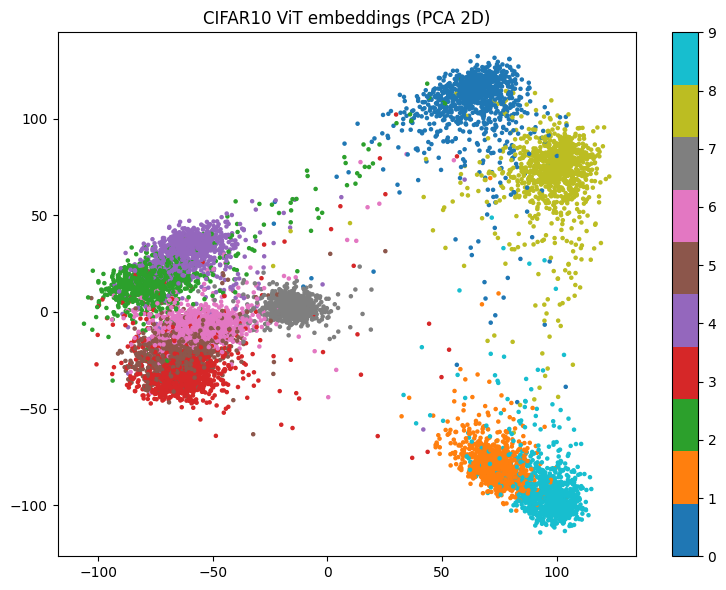

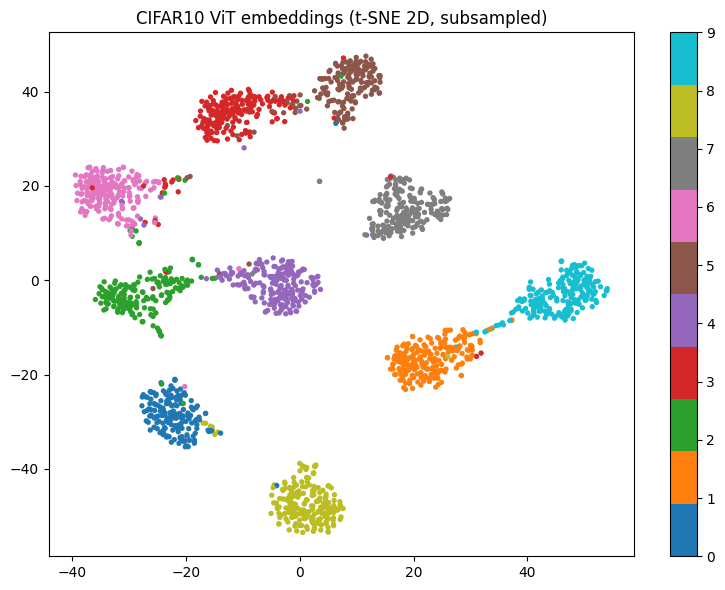

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch.nn.functional as F

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "google/vit-base-patch16-224-in21k"
processor = processor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)
model = AutoModelForImageClassification.from_pretrained(model_name, num_labels=10, ignore_mismatched_sizes=True).to(device)
model.config.output_hidden_states = True


# CIFAR10 gives PIL images; we will use processor to resize/normalize
train_ds = datasets.CIFAR10(root="./data", train=True, download=True)
test_ds  = datasets.CIFAR10(root="./data", train=False, download=True)

def collate_fn(batch):
    images = [x[0] for x in batch]   # PIL
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    inputs = processor(images=images, return_tensors="pt")
    return inputs, labels

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, collate_fn=collate_fn)

# ---- Optional short fine-tune ----
model.train()
opt = torch.optim.AdamW(model.parameters(), lr=2e-5)

steps = 200  # keep small (bonus)
it = iter(train_loader)
for step in range(1, steps + 1):
    try:
        inputs, labels = next(it)
    except StopIteration:
        it = iter(train_loader)
        inputs, labels = next(it)

    inputs = {k: v.to(device) for k, v in inputs.items()}
    labels = labels.to(device)

    out = model(**inputs, labels=labels)
    loss = out.loss

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 40 == 0:
        print(f"step {step}/{steps} | loss {loss.item():.4f}")

# ---- Extract embeddings from test set ----
model.eval()
emb_list = []
y_list = []

# Use the CLS token embedding from last hidden state as image embedding
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        last_hidden = outputs.hidden_states[-1]      # (B, tokens, hidden)
        cls_emb = last_hidden[:, 0, :]               # (B, hidden)
        emb_list.append(cls_emb.cpu())
        y_list.append(labels)

emb = torch.cat(emb_list, dim=0).numpy()
y = torch.cat(y_list, dim=0).numpy()

# ---- PCA plot ----
pca = PCA(n_components=2, random_state=0)
E2 = pca.fit_transform(emb)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(E2[:, 0], E2[:, 1], c=y, s=5, cmap="tab10")
plt.title("CIFAR10 ViT embeddings (PCA 2D)")
plt.colorbar(scatter, ticks=range(10))
plt.tight_layout()
plt.show()

# ---- t-SNE plot (slower; subsample to speed up) ----
n = 2000
idx = np.random.RandomState(0).choice(len(y), size=n, replace=False)
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random", random_state=0)
Et = tsne.fit_transform(emb[idx])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Et[:, 0], Et[:, 1], c=y[idx], s=8, cmap="tab10")
plt.title("CIFAR10 ViT embeddings (t-SNE 2D, subsampled)")
plt.colorbar(scatter, ticks=range(10))
plt.tight_layout()
plt.show()
